In [1]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
db=mysql.connector.connect(host="localhost",user="root",password="270511",database="sales_data")

In [3]:
df=pd.read_sql("SELECT * FROM sales_data", con=db)
df.head()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9944\3914784013.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql("SELECT * FROM sales_data", con=db)


,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [4]:
query="select Product_Category, sum(Quantity_Sold) as Total_Quantity from sales_data group by Product_Category order by Total_Quantity desc limit 10"

In [5]:
df=pd.read_sql_query(query, con=db)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9944\176539514.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql_query(query, con=db)


  Product_Category  Total_Quantity
0         Clothing          6922.0
1        Furniture          6729.0
2      Electronics          6096.0
3             Food          5608.0


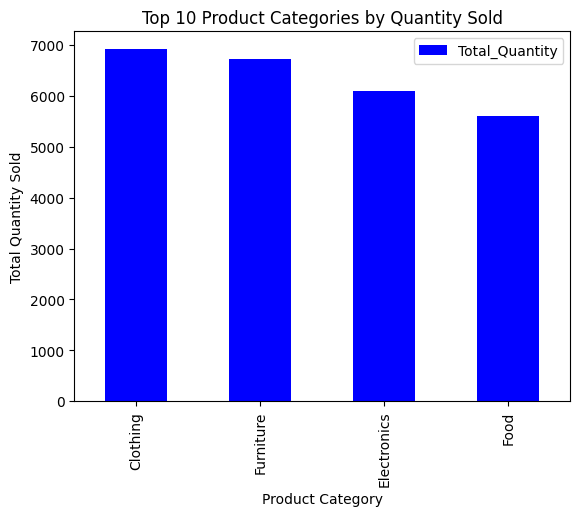

In [6]:
print(df)
df.plot(kind='bar', x='Product_Category', y='Total_Quantity', color='blue')
plt.title('Top 10 Product Categories by Quantity Sold')
plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')  
plt.show()

In [7]:
query="select Product_Category, sum(Quantity_Sold) as Total_Quantity,sum(Unit_Price*Quantity_Sold)as Total_Revenue from sales_data group by Product_Category order by Total_Quantity desc limit 10"

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9944\3883086719.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df1=pd.read_sql_query(query, con=db)


  Product_Category  Total_Quantity  Total_Revenue
0         Clothing          6922.0    19286733.93
1        Furniture          6729.0    18330280.56
2      Electronics          6096.0    17571040.57
3             Food          5608.0    15141885.65


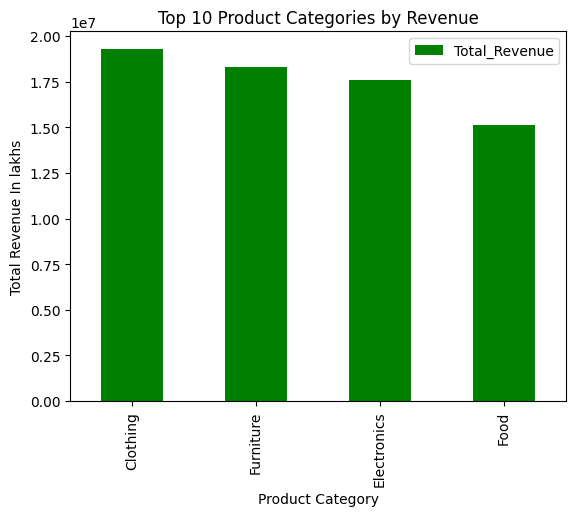

In [13]:
df1=pd.read_sql_query(query, con=db)
print(df1)
df1.plot(kind='bar', x='Product_Category', y='Total_Revenue', color='green')
plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue In lakhs')
plt.show()